In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [6]:
X, y_true = make_blobs(n_samples = 500, centers = 3, cluster_std = 0.6) 

In [7]:
df = pd.DataFrame(X, columns = ['Feature_1', 'Feature_2']) 

In [8]:
df

,Feature_1,Feature_2
0,7.558046,-7.919824
1,7.701662,-8.481028
2,-6.843814,-6.918048
3,-6.411765,-6.124432
4,-7.707295,-7.093781
...,...,...
495,-7.576683,-6.108925
496,6.584981,-8.525867
497,5.012512,-7.706874
498,6.325163,-7.645824


In [9]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [10]:
inertia = []
K_range = range(1, 11)

In [11]:
for k in K_range: 
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(df_scaled)
    # inertia.append({'K' : k, 'Inertia' : kmeans.inertia_})
    inertia.append(kmeans.inertia_)

In [12]:
inertia

[1000.0000000000002,
 389.98956127619243,
 8.840286344123085,
 7.73374066045122,
 6.192082268773938,
 6.899319477220407,
 5.282484843457306,
 4.190380518343414,
 3.931492209103359,
 3.488454217998468]

In [13]:
import matplotlib.pyplot as plt

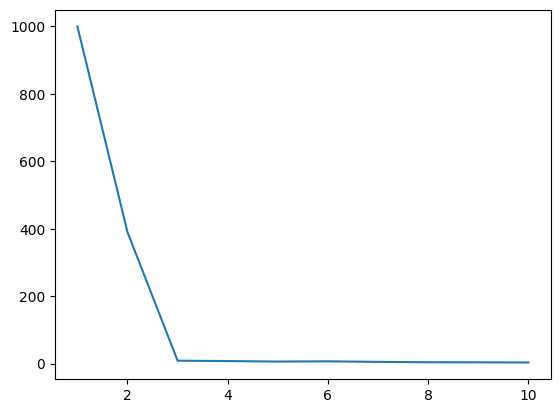

In [14]:
plt.plot(K_range, inertia)

In [15]:
kmeans_model = KMeans(n_clusters = 3)

In [16]:
cluster_labels = kmeans_model.fit_predict(df_scaled)

In [17]:
cluster_labels

array([0, 0, 2, 2, 2, 1, 0, 1, 2, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 0, 2,
       2, 2, 1, 1, 2, 2, 0, 0, 1, 0, 2, 1, 0, 0, 2, 2, 0, 1, 2, 2, 1, 2,
       0, 2, 1, 0, 1, 2, 0, 0, 1, 0, 0, 2, 0, 2, 0, 2, 2, 1, 2, 2, 0, 0,
       2, 0, 2, 1, 1, 0, 2, 1, 1, 2, 0, 2, 0, 2, 2, 2, 1, 1, 2, 1, 1, 1,
       2, 0, 1, 1, 0, 0, 2, 1, 2, 0, 2, 1, 1, 2, 0, 0, 0, 1, 2, 0, 2, 0,
       0, 2, 1, 2, 2, 2, 2, 2, 1, 0, 1, 0, 2, 0, 1, 2, 0, 1, 1, 0, 1, 2,
       0, 2, 0, 1, 0, 1, 0, 1, 1, 2, 0, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 0,
       1, 2, 2, 2, 1, 2, 0, 2, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       2, 1, 2, 0, 2, 2, 1, 0, 1, 1, 1, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 1, 0, 0, 1, 2, 1, 0, 2, 0, 0, 2, 2, 0, 1, 0, 1, 1, 2,
       0, 1, 1, 2, 1, 2, 0, 0, 0, 2, 0, 2, 0, 0, 1, 2, 0, 1, 2, 2, 1, 2,
       2, 0, 1, 1, 2, 2, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 2, 0, 1, 0, 1,
       0, 2, 1, 0, 1, 0, 1, 2, 1, 1, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2, 1, 2,
       1, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 2, 1, 2,

In [19]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

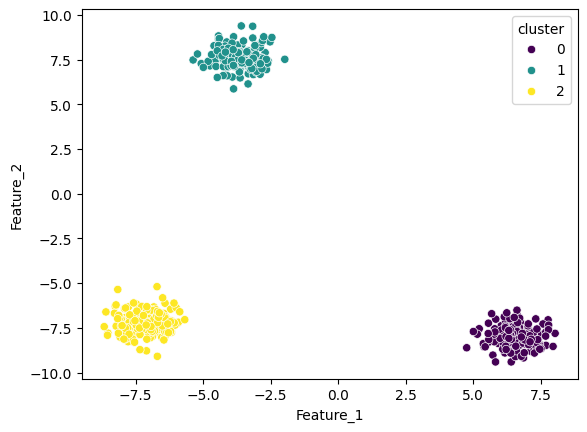

In [20]:
sns.scatterplot(
    x = df['Feature_1'],
    y = df['Feature_2'],
    hue = df['cluster'],
    palette='viridis'
)

In [21]:
from pyclustering.cluster.kmedoids import kmedoids

In [22]:
initial_medoids = [1, 200, 350]
kmedoids_model = kmedoids(df_scaled, initial_medoids)

In [23]:
kmedoids_model.process()
clusters = kmedoids_model.get_clusters()
print(clusters)

[[0, 1, 6, 9, 10, 11, 13, 14, 17, 18, 19, 20, 28, 29, 31, 34, 35, 38, 44, 47, 50, 51, 53, 54, 56, 58, 64, 65, 67, 71, 76, 78, 89, 92, 93, 97, 102, 103, 104, 107, 109, 110, 119, 121, 123, 126, 129, 132, 134, 136, 138, 142, 153, 160, 163, 166, 168, 172, 173, 179, 183, 187, 188, 201, 203, 204, 208, 210, 211, 214, 216, 220, 226, 227, 228, 230, 232, 233, 236, 243, 250, 251, 254, 255, 256, 258, 260, 262, 264, 267, 269, 274, 281, 295, 296, 297, 304, 307, 308, 309, 311, 313, 315, 324, 326, 327, 334, 336, 337, 341, 342, 345, 347, 348, 349, 353, 356, 360, 361, 363, 368, 369, 370, 373, 375, 382, 386, 388, 389, 391, 392, 394, 399, 401, 406, 407, 411, 414, 421, 422, 426, 429, 433, 437, 438, 444, 446, 448, 450, 457, 458, 460, 463, 464, 465, 470, 471, 477, 484, 485, 489, 491, 492, 493, 496, 497, 498], [2, 3, 4, 8, 15, 21, 22, 23, 26, 27, 32, 36, 37, 40, 41, 43, 45, 49, 55, 57, 59, 60, 62, 63, 66, 68, 72, 75, 77, 79, 80, 81, 84, 88, 94, 96, 98, 101, 106, 108, 111, 113, 114, 115, 116, 117, 122, 125, 13

In [25]:
assigned_cluster = []
for i in range(500):
    assigned_cluster.append(0)
    
for i in range(3) :
    for n in clusters[i]:
        assigned_cluster[n] = i

print(assigned_cluster)

[0, 0, 1, 1, 1, 2, 0, 2, 1, 0, 0, 0, 2, 0, 0, 1, 2, 0, 0, 0, 0, 1, 1, 1, 2, 2, 1, 1, 0, 0, 2, 0, 1, 2, 0, 0, 1, 1, 0, 2, 1, 1, 2, 1, 0, 1, 2, 0, 2, 1, 0, 0, 2, 0, 0, 1, 0, 1, 0, 1, 1, 2, 1, 1, 0, 0, 1, 0, 1, 2, 2, 0, 1, 2, 2, 1, 0, 1, 0, 1, 1, 1, 2, 2, 1, 2, 2, 2, 1, 0, 2, 2, 0, 0, 1, 2, 1, 0, 1, 2, 2, 1, 0, 0, 0, 2, 1, 0, 1, 0, 0, 1, 2, 1, 1, 1, 1, 1, 2, 0, 2, 0, 1, 0, 2, 1, 0, 2, 2, 0, 2, 1, 0, 1, 0, 2, 0, 2, 0, 2, 2, 1, 0, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 0, 2, 1, 1, 1, 2, 1, 0, 1, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 1, 2, 1, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 0, 0, 2, 1, 2, 0, 1, 0, 0, 1, 1, 0, 2, 0, 2, 2, 1, 0, 2, 2, 1, 2, 1, 0, 0, 0, 1, 0, 1, 0, 0, 2, 1, 0, 2, 1, 1, 2, 1, 1, 0, 2, 2, 1, 1, 2, 2, 0, 0, 2, 2, 0, 0, 0, 2, 0, 1, 0, 2, 0, 2, 0, 1, 2, 0, 2, 0, 2, 1, 2, 2, 0, 2, 1, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 1, 1, 2, 2, 2, 2, 2, 1, 0, 1, 0, 0, 1, 2, 2, 1, 1, 

In [26]:
df['cluster'] = assigned_cluster

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

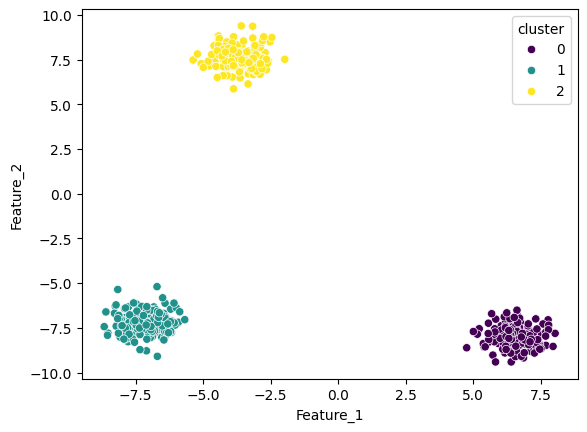

In [27]:
sns.scatterplot(
    x = df['Feature_1'],
    y = df['Feature_2'],
    hue = df['cluster'],
    palette='viridis'
)

In [28]:
from sklearn.datasets import make_moons

In [29]:
X, y_true = make_moons(n_samples = 500, noise = 0.05)

In [30]:
from sklearn.cluster import DBSCAN

In [31]:
df = pd.DataFrame(X, columns = ['Feature_1', 'Feature_2'])

In [33]:
df_scaled = scaler.fit_transform(df)

In [34]:
kmeans = KMeans(n_clusters = 2)
df['kmeans-cluster'] = kmeans.fit_predict(df_scaled)

In [42]:
dbscan_model = DBSCAN(eps = 0.3, min_samples = 5)
df['dbscan-cluster'] = dbscan_model.fit_predict(df_scaled)

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

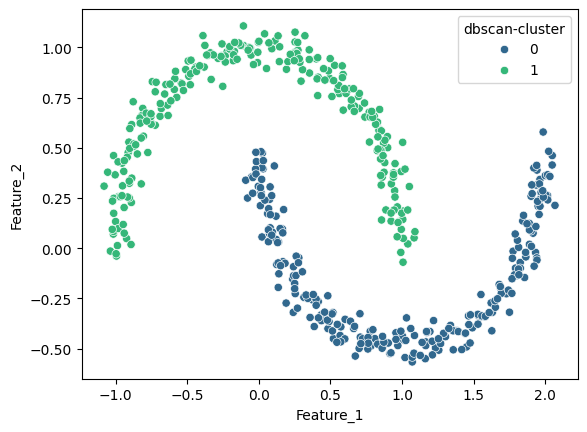

In [44]:
sns.scatterplot(
    x = df['Feature_1'],
    y = df['Feature_2'],
    hue = df['dbscan-cluster'],
    palette='viridis'
)

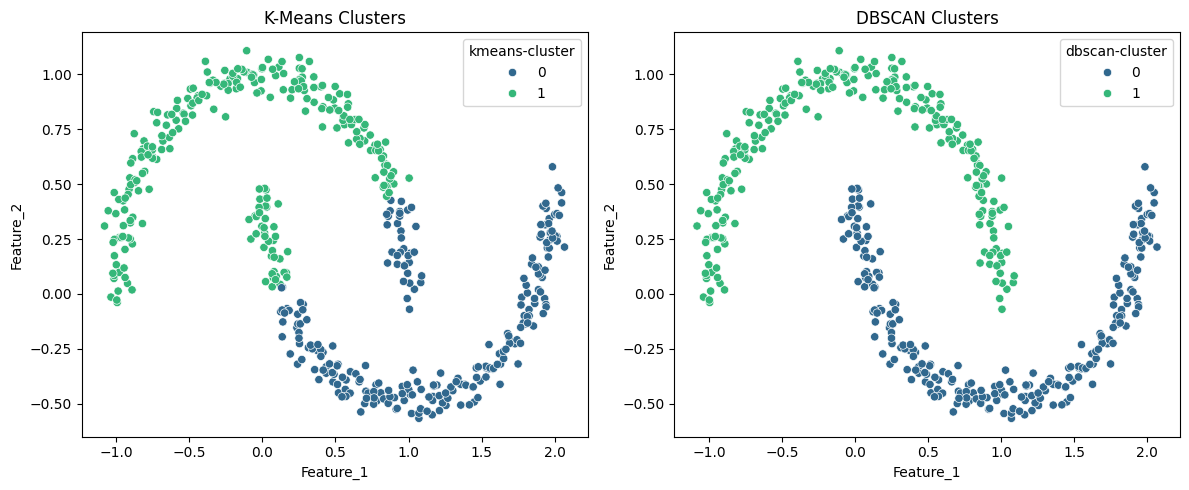

In [45]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df,
    x='Feature_1',
    y='Feature_2',
    hue='kmeans-cluster',
    palette='viridis'
)
plt.title("K-Means Clusters")

plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df,
    x='Feature_1',
    y='Feature_2',
    hue='dbscan-cluster',
    palette='viridis'
)
plt.title("DBSCAN Clusters")

plt.tight_layout()
plt.show()